In [22]:
from Benchmarks import FLOWSTAR_benchmarks, JUILIAREACH_benchmarks, ARCH_benchmarks, C2E2_benchmarks
from TERA.Workbench.Task import TaskRunner
from TERA.Workbench.Visualizer import Visualizer

tasks = FLOWSTAR_benchmarks.get_chen_continuous()

This notebook primarily contains benchmarks that were meant to validate the single step Flow*-style mode, but ran through the left right INTLAB-style mode to evaluate difference in tightness & computation time.

## Xin Chen (Flowstar): Thesis Examples

### Example 3.3.9: Jet Engine


[TaskRunner] Initializing continuous task: Jet Engine (Example 3.3.9)

--- Starting CONTINUOUS Test: Jet Engine (Example 3.3.9) ---
Mode: left_right
System: [-0.5*x^3 - 1.5*x^2 - y - 0.5, 3*x - y]
Fixed Step Mode: True, Preconditioning: ID
Initial Set: [Interval([0.900000000000000, 1.10000000000001]), Interval([0.900000000000000, 1.10000000000001])]
Time: [0, 10.0], Step: 0.02, Order: 4
----------------------------------------------------------------------
STATUS: SUCCESS. Total computation time: 36.4861 seconds
Computed 501 segments.
----------------------------------------------------------------------

Final Reachable Set Bounds (t_end)
Dim        | Interval                       | Width       
------------------------------------------------------------
x          | [  -0.30133,   -0.29063]       | 0.010699    
y          | [  -0.65059,   -0.63083]       | 0.019759    

--- FINAL STATE VALIDATION ---
x          | [-0.301328, -0.290630] (Width: 0.010699)
y          | [-0.650586, -0

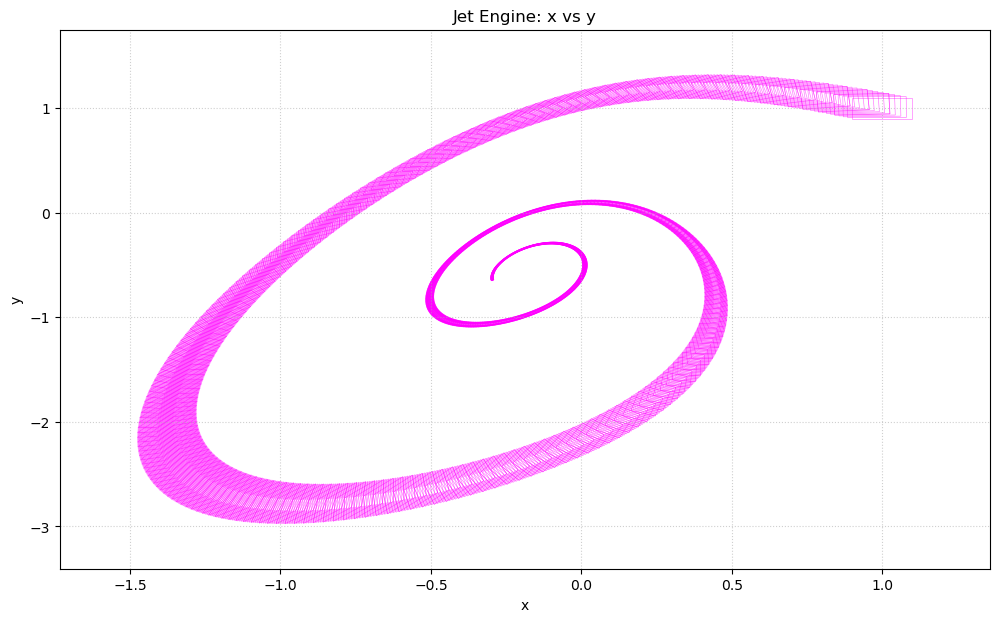

In [2]:
task = tasks["cont_jet_engine"]
task.engine_params.update({"setting": "left_right"})
result_lv = TaskRunner.run(task)
plot = Visualizer.plot(result_lv, title="Jet Engine: x vs y")

### Example 3.3.11: Lotka Volterra


[TaskRunner] Initializing continuous task: Lotka-Volterra (Example 3.3.11)

--- Starting CONTINUOUS Test: Lotka-Volterra (Example 3.3.11) ---
Mode: left_right
System: [-x*y + 1.5*x, x*y - 3*y]
Fixed Step Mode: True, Preconditioning: ID
Initial Set: [Interval([4.95000000000000, 5.05000000000000]), Interval([1.94999999999999, 2.05000000000000])]
Time: [0, 4.0], Step: 0.01, Order: 5
----------------------------------------------------------------------
STATUS: SUCCESS. Total computation time: 45.4385 seconds
Computed 401 segments.
----------------------------------------------------------------------

--- FINAL STATE VALIDATION ---
x          | [1.611857, 1.688413] (Width: 0.076557)
y          | [2.045109, 2.136082] (Width: 0.090973)

Comparing against expected benchmarks...

  FAIL: x (Does not enclose or match within tolerance)
    Computed: Interval([1.61185666014075, 1.68841345611151])
    Expected: Interval([1.61147354201700, 1.68842650314001])
    Diff: L=3.83e-04, U=1.30e-05

  FA

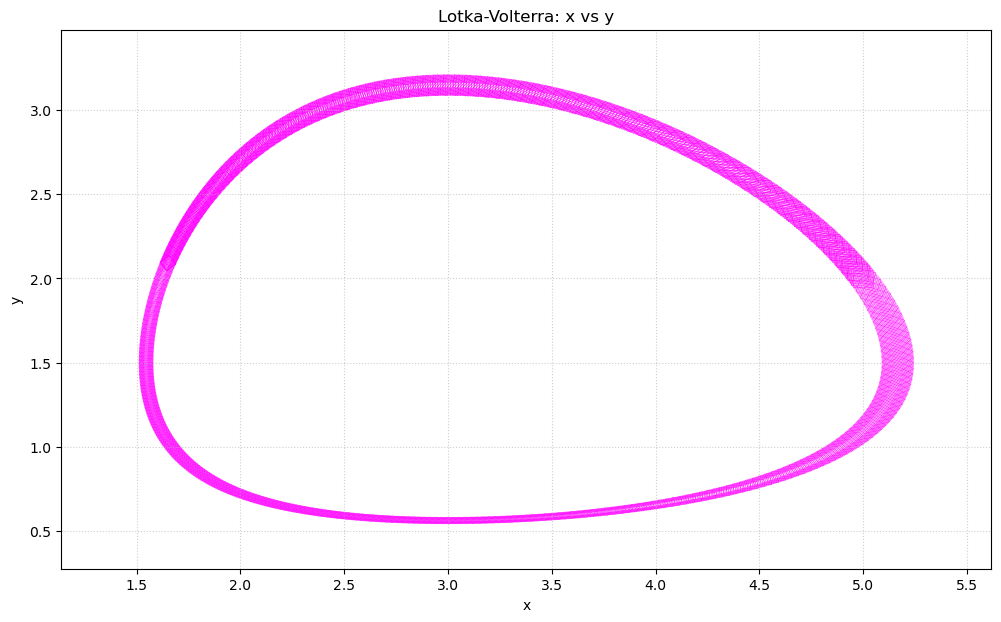

In [5]:
task = tasks["cont_lotka_volterra"]
task.engine_params.update({"setting": "left_right"})
result_lv = TaskRunner.run(task)
plot = Visualizer.plot(result_lv, title="Lotka-Volterra: x vs y")

### Example 3.4.2: Lorenz System


[TaskRunner] Initializing continuous task: Lorenz (Example 3.4.2)


L-R Reachability:   0%|          | 0/7.0 [00:00<?, ?it/s]


Min step reached at t=0.8442295887200001. Abort.

--- Starting CONTINUOUS Test: Lorenz (Example 3.4.2) ---
Mode: left_right
System: [-10*x + 10*y, -x*(z - 28) - y, x*y - 2.6666666666666665*z]
Fixed Step Mode: False, Preconditioning: ID
Initial Set: [Interval([14.9990000000000, 15.0010000000000]), Interval([14.9990000000000, 15.0010000000000]), Interval([35.9990000000000, 36.0010000000000])]
Time: [0, 7.00000000000000], Step: 0.02, Order: 5
----------------------------------------------------------------------
STATUS: FAIL_MIN_STEP. Total computation time: 96.4055 seconds
Computed 44 segments.
----------------------------------------------------------------------


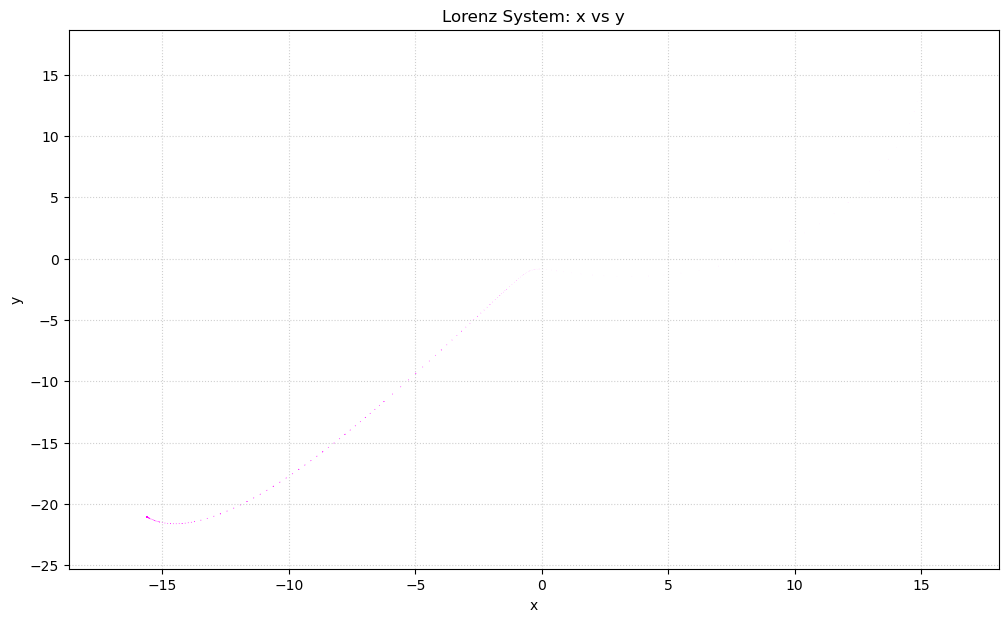

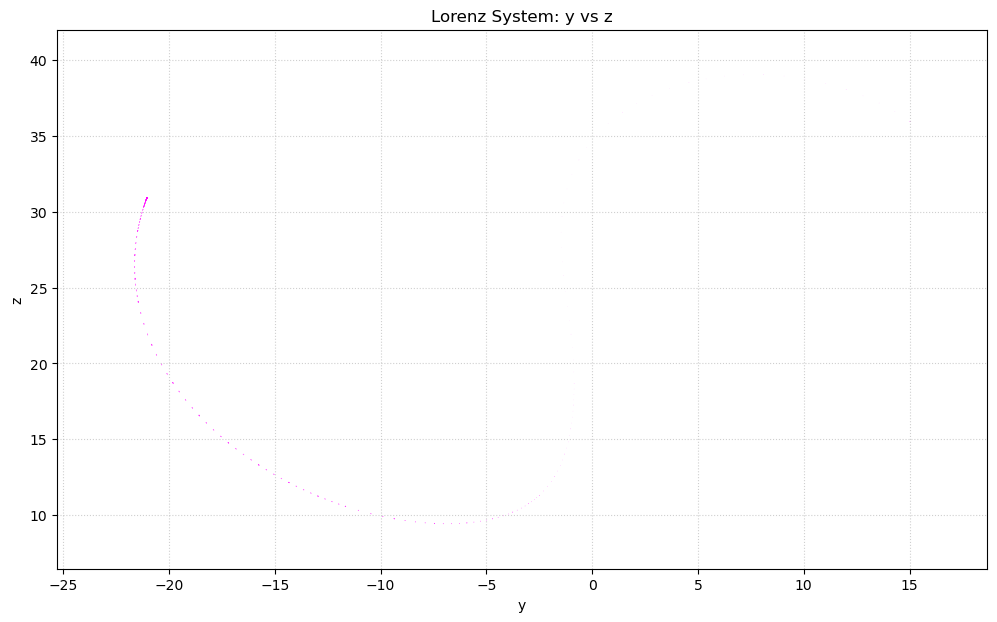

In [ ]:
task_lor = tasks["cont_lorenz_chen"]
task_lor.time_horizon = 7.0
task_lor.order = 5 # brought down from 7
task_lor.step_size = 0.1
task_lor.engine_params.update({"setting": "left_right"})

result_lv = TaskRunner.run(task_lor, progress_bar=True)
plot = Visualizer.plot(result_lv, title="Lorenz System: x vs y")
plot = Visualizer.plot(result_lv, dims=(1,2), title="Lorenz System: y vs z")

### Example 3.4.3: Rossler Attractor


[TaskRunner] Initializing continuous task: Rössler Attractor (Example 3.4.3)


L-R Reachability:   0%|          | 0/4.0 [00:00<?, ?it/s]


--- Starting CONTINUOUS Test: Rössler Attractor (Example 3.4.3) ---
Mode: left_right
System: [-y - z, x + 0.2*y, (x - 5.7)*z + 0.2]
Fixed Step Mode: True, Preconditioning: ID
Initial Set: [Interval([-0.200000000000001, 0.200000000000001]), Interval([-8.60000000000000, -8.19999999999999]), Interval([-0.200000000000001, 0.200000000000001])]
Time: [0, 4.0], Step: 0.01, Order: 5
----------------------------------------------------------------------
STATUS: SUCCESS. Total computation time: 710.0836 seconds
Computed 401 segments.
----------------------------------------------------------------------

Final Reachable Set Bounds (t_end)
Dim        | Interval                       | Width       
------------------------------------------------------------
x          | [  -7.44309,   -5.89460]       | 1.548487    
y          | [   1.83961,    3.54402]       | 1.704417    
z          | [   0.01556,    0.01754]       | 0.001974    


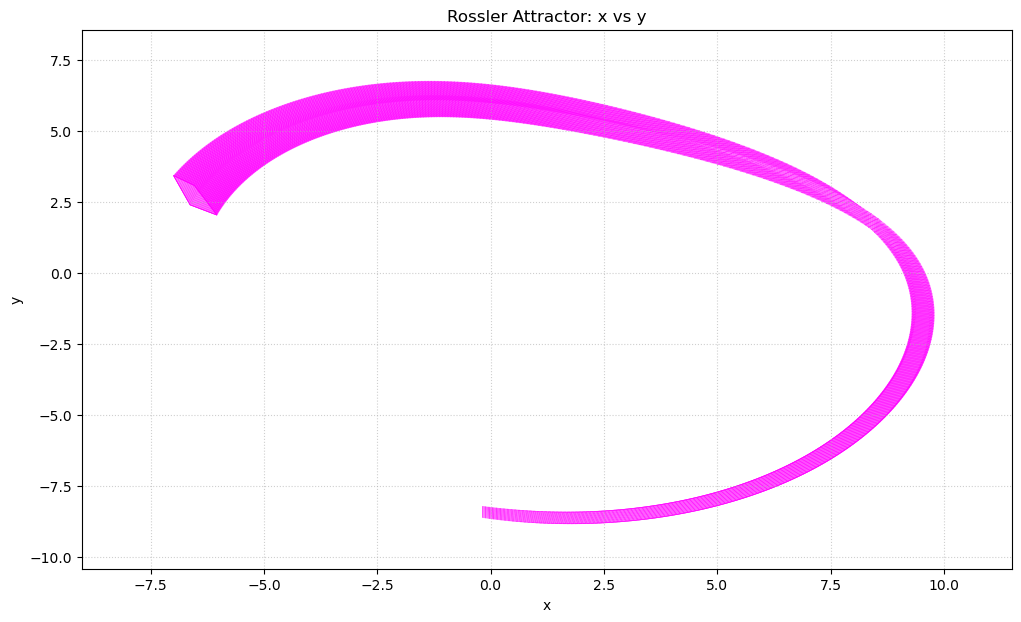

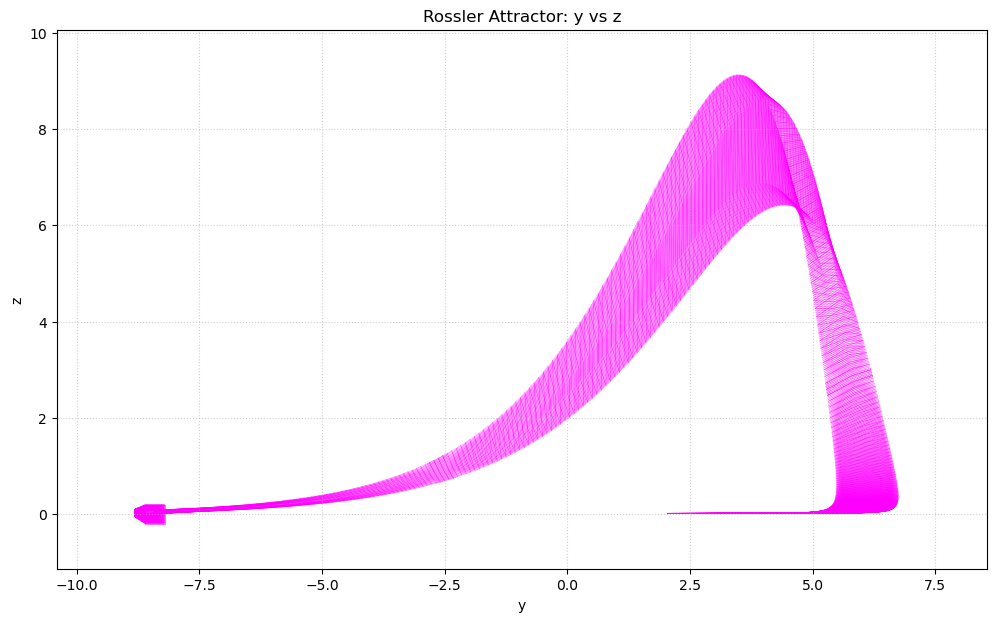

In [5]:
task = tasks["cont_rossler"]
task.order = 5 # brought down from 10
task.engine_params.update({"setting": "left_right"})

result_lv = TaskRunner.run(task, progress_bar=True)
plot = Visualizer.plot(result_lv, title="Rossler Attractor: x vs y")
plot = Visualizer.plot(result_lv, dims=(1,2), title="Rossler Attractor: y vs z")

### Example 5.2.1: Van der Pol


[TaskRunner] Initializing continuous task: Van der Pol (Example 5.2.1)


L-R Reachability:   0%|          | 0/7.0 [00:00<?, ?it/s]


--- Starting CONTINUOUS Test: Van der Pol (Example 5.2.1) ---
Mode: left_right
System: [y, -(x^2 - 1)*y - x]
Fixed Step Mode: True, Preconditioning: ID
Initial Set: [Interval([1.25000000000000, 1.55000000000001]), Interval([2.35000000000000, 2.45000000000001])]
Time: [0, 7.0], Step: 0.02, Order: 5
----------------------------------------------------------------------
STATUS: SUCCESS. Total computation time: 73.5941 seconds
Computed 351 segments.
----------------------------------------------------------------------

Final Reachable Set Bounds (t_end)
Dim        | Interval                       | Width       
------------------------------------------------------------
x          | [   1.79828,    1.92893]       | 0.130646    
y          | [   0.76632,    1.29072]       | 0.524406    


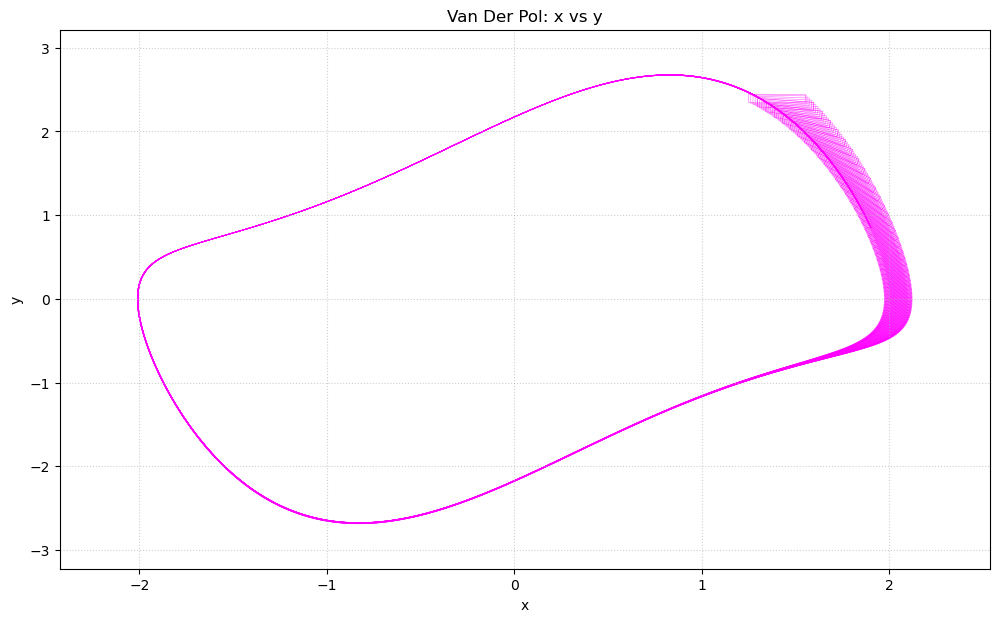

In [7]:
task = tasks["cont_vanderpol"]
task.engine_params.update({"setting": "left_right"})

result_lv = TaskRunner.run(task, progress_bar=True)
plot = Visualizer.plot(result_lv, title="Van Der Pol: x vs y")

### Example 5.2.4: Biological Model I

In [ ]:
task = tasks["cont_bio"]
task.engine_params.update({"setting": "left_right"})
result_lv = TaskRunner.run(task, progress_bar=True)
plot = Visualizer.plot(result_lv, title="Biological Model: x1 vs x2")